# Hybrid Quantum Machine Learning Platform for Early Disease Detection
## Stage 04-B: Training 4-Qubit Noisy Variational Quantum Classifier (VQC) with Realistic NISQ Noise Channels
**Target Application:** Lung Cancer Classification  
**Target Variable:** `LUNG_CANCER` (0 = NO, 1 = YES)  
**Input Features (4 Selected):** `WHEEZING`, `YELLOW_FINGERS`, `AGE`, `SHORTNESS_OF_BREATH`  
**Quantum Framework:** PennyLane (Density Matrix Simulation on `default.mixed`)  

---

### Architectural & Noise Model Specification
* **Quantum Device:** `default.mixed` (4 wires, density matrix simulator for open quantum systems).
* **Data Encoding (Feature Vector $x$):**
  * $x_1 \to RY(x_1 \cdot \pi)$ on Wire 0 (`WHEEZING`)
  * $x_2 \to RY(x_2 \cdot \pi)$ on Wire 1 (`YELLOW_FINGERS`)
  * $x_3 \to RY(x_3 \cdot \pi)$ on Wire 2 (`AGE`)
  * $x_4 \to RY(x_4 \cdot \pi)$ on Wire 3 (`SHORTNESS_OF_BREATH`)
* **VQC Layer 1 (Trainable Parameters $\theta$):**
  * Parameterized single-qubit rotations: $RY(\theta_1), RY(\theta_3), RY(\theta_5), RY(\theta_7)$
  * Single-qubit depolarizing noise: $p_{gate} = 0.005$ (0.5% error per rotation)
  * CNOT Entanglement (Linear chain): CNOT(0, 1), CNOT(1, 2), CNOT(2, 3)
  * Two-qubit depolarizing noise: $p_{cnot} = 0.020$ (2.0% error per CNOT)
* **VQC Layer 2 (Trainable Parameters $\theta$):**
  * Parameterized single-qubit rotations: $RY(\theta_2), RY(\theta_4), RY(\theta_6), RY(\theta_8)$
  * Single-qubit depolarizing noise: $p_{gate} = 0.005$
  * CNOT Entanglement (Linear chain): CNOT(0, 1), CNOT(1, 2), CNOT(2, 3)
  * Two-qubit depolarizing noise: $p_{cnot} = 0.020$
* **Measurement & Readout Error (SPAM):**
  * Bit-flip error channel on each wire prior to measurement: $p_{meas} = 0.015$ (1.5% readout error)
  * Observable: Pauli-Z expectation on all 4 qubits: $\langle Z_i \rangle$
  * Pooled "Z Expectation": $\langle Z \rangle = \frac{1}{4} \sum_{i=0}^3 \langle Z_i \rangle$
* **Classical Optimization Loop:**
  * Classification head: $\hat{p} = \sigma(\langle Z \rangle + b)$
  * Loss: Binary Cross-Entropy (BCE) with $\epsilon$-clipping
  * Optimizer: PennyLane Adam Optimizer
  * Checkpointing: Best model weights saved according to lowest validation loss.


In [1]:
# ==============================================================================
# 0. SETUP, IMPORTS & PATH CONFIGURATION
# ==============================================================================

import os
os.environ["MPLCONFIGDIR"] = "/tmp"

import json
import time
from pathlib import Path

import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Robust Base Directory Finder
current_notebook_dir = Path.cwd().resolve()
base_dir = current_notebook_dir
while not (base_dir / "artifacts").exists() and base_dir.parent != base_dir:
    base_dir = base_dir.parent

FS_ARTIFACTS_DIR = base_dir / "artifacts" / "feature_selection"
PREP_ARTIFACTS_DIR = base_dir / "artifacts" / "preprocessing"
NOISELESS_DIR = base_dir / "Train_models" / "Hybrid_Quantum_ML" / "4-feature_Vqc"
OUTPUT_MODEL_DIR = base_dir / "Train_models" / "Hybrid_Quantum_ML" / "4-Feature_VQC_Noisy"
FIGURES_DIR = OUTPUT_MODEL_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pnp.random.seed(RANDOM_STATE)

print("Environment Configuration:")
print(f"  PennyLane Version: {qml.__version__}")
print(f"  Base Directory:    {base_dir}")
print(f"  Output Directory:  {OUTPUT_MODEL_DIR}")
print(f"  Figures Directory: {FIGURES_DIR}")


Environment Configuration:
  PennyLane Version: 0.45.1
  Base Directory:    /home/logith-p/Desktop/hybrid-qml-disease-detection
  Output Directory:  /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/4-Feature_VQC_Noisy
  Figures Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/4-Feature_VQC_Noisy/figures


---
## 1. Load Preprocessed 4-Feature Datasets

We load the strictly leakage-free 4-feature datasets generated by `03_feature_engineering_selection.ipynb`:
* `X_train_4.csv` & `y_train.csv` (70% partition, 2,098 samples)
* `X_validation_4.csv` & `y_validation.csv` (15% partition, 450 samples)
* `X_test_4.csv` & `y_test.csv` (15% holdout partition, 450 samples)


In [2]:
# ==============================================================================
# 1. LOAD 4-FEATURE DATASETS
# ==============================================================================

with open(FS_ARTIFACTS_DIR / "selected_features.json", "r") as f:
    selected_features = json.load(f)

X_train_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_train_4.csv")
X_val_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_validation_4.csv")
X_test_df = pd.read_csv(FS_ARTIFACTS_DIR / "X_test_4.csv")

y_train = pd.read_csv(PREP_ARTIFACTS_DIR / "y_train.csv").squeeze().values.astype(float)
y_val = pd.read_csv(PREP_ARTIFACTS_DIR / "y_validation.csv").squeeze().values.astype(float)
y_test = pd.read_csv(PREP_ARTIFACTS_DIR / "y_test.csv").squeeze().values.astype(float)

X_train = X_train_df.values.astype(float)
X_val = X_val_df.values.astype(float)
X_test = X_test_df.values.astype(float)

print("================================================================================")
print(" 4-FEATURE DATASET SUMMARY")
print("================================================================================")
print(f"Selected Features:     {selected_features}")
print(f"Training Samples:      {len(X_train):,} ({X_train.shape[1]} features)")
print(f"Validation Samples:    {len(X_val):,} ({X_val.shape[1]} features)")
print(f"Test Samples:          {len(X_test):,} ({X_test.shape[1]} features)")
print(f"Feature Value Range:   [{X_train.min():.2f}, {X_train.max():.2f}] (Scaled to [0, 1])")
print("================================================================================\n")

display(X_train_df.head(3))


 4-FEATURE DATASET SUMMARY
Selected Features:     ['WHEEZING', 'YELLOW_FINGERS', 'AGE', 'SHORTNESS_OF_BREATH']
Training Samples:      2,098 (4 features)
Validation Samples:    450 (4 features)
Test Samples:          450 (4 features)
Feature Value Range:   [0.00, 1.00] (Scaled to [0, 1])



,WHEEZING,YELLOW_FINGERS,AGE,SHORTNESS_OF_BREATH
0,1.0,0.0,0.48,0.0
1,1.0,1.0,0.00,0.0
2,0.0,0.0,0.82,1.0


---
## 2. Quantum Device & Noisy 4-Qubit 2-Layer VQC Architecture

### Mathematical Noise Formulation
In realistic Noisy Intermediate-Scale Quantum (NISQ) processors, state evolution is non-unitary and modeled by completely positive trace-preserving (CPTP) maps acting on density matrices $\rho$:

1. **Single-Qubit Gate Depolarizing Channel ($\mathcal{E}_{1q}$)**:
   $$\mathcal{E}_{depol}(\rho) = (1 - p_{gate}) \rho + \frac{p_{gate}}{3} (X\rho X + Y\rho Y + Z\rho Z)$$
   Applied after every single-qubit $RY$ rotation gate ($p_{gate} = 0.005$, i.e. 0.5% infidelity).

2. **Two-Qubit Entanglement Depolarizing Channel ($\mathcal{E}_{2q}$)**:
   Two-qubit CNOT entanglers suffer from significantly higher physical decoherence and cross-talk on superconducting qubits:
   $$\mathcal{E}_{2q}(\rho) = (1 - p_{cnot}) \rho + \frac{p_{cnot}}{15} \sum_{i,j \in \{I,X,Y,Z\}, (i,j) \neq (I,I)} (P_i \otimes P_j) \rho (P_i \otimes P_j)$$
   Applied across both control and target wires for each CNOT ladder gate ($p_{cnot} = 0.020$, i.e. 2.0% infidelity).

3. **Readout Measurement Error / State Preparation and Measurement (SPAM) ($\mathcal{E}_{meas}$)**:
   Modeled via a bit-flip channel immediately preceding projective Z-basis readout:
   $$\mathcal{E}_{meas}(\rho) = (1 - p_{meas}) \rho + p_{meas} X\rho X$$
   where $p_{meas} = 0.015$ (1.5% readout error).

4. **Observable**:
   Expectation value of Pauli-Z on all 4 qubits: $\langle Z_i \rangle = \text{Tr}(\rho Z_i)$, pooled into $\langle Z \rangle = \frac{1}{4} \sum_{i=0}^3 \langle Z_i \rangle$.


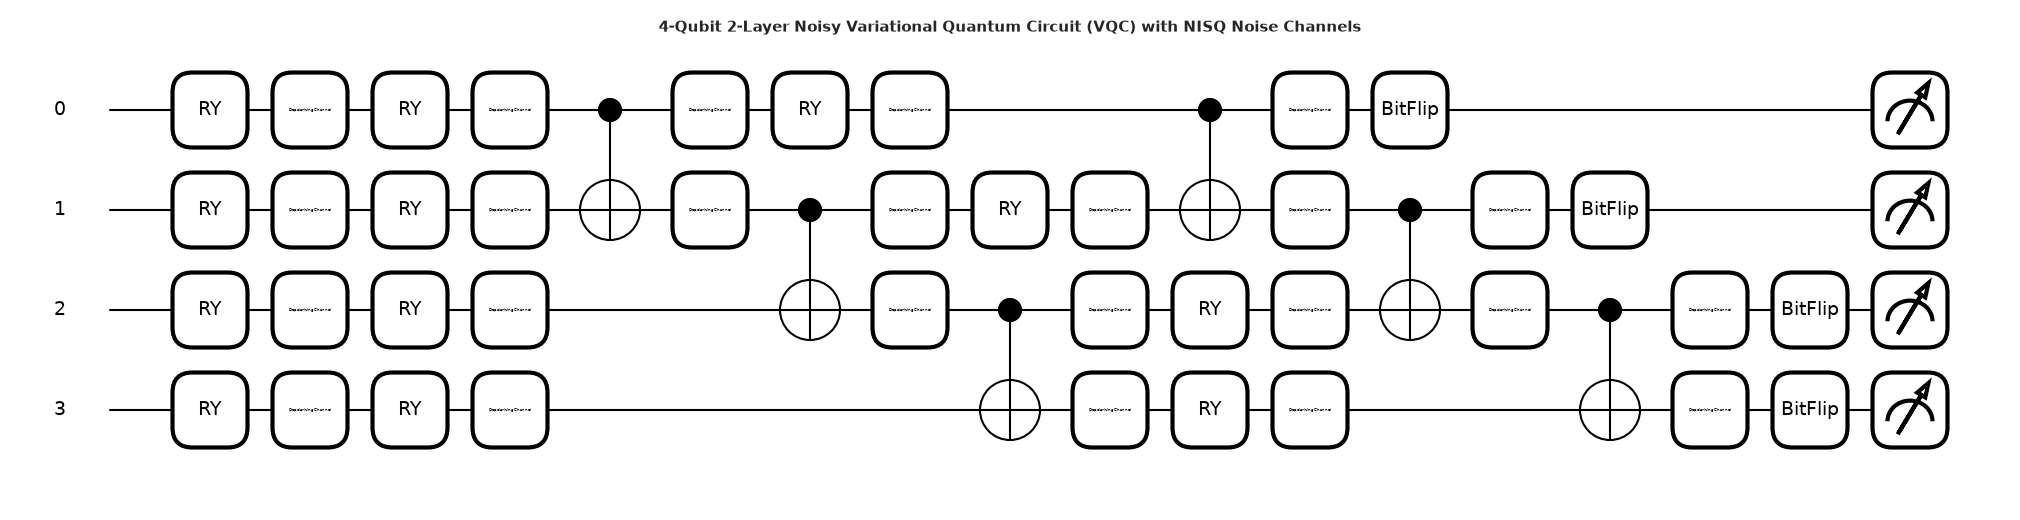

Quantum Circuit Architecture (ASCII):
0: ──RY(3.14)──DepolarizingChannel(0.01)──RY(0.00)──DepolarizingChannel(0.01)─╭● ···
1: ──RY(0.00)──DepolarizingChannel(0.01)──RY(0.00)──DepolarizingChannel(0.01)─╰X ···
2: ──RY(1.51)──DepolarizingChannel(0.01)──RY(0.00)──DepolarizingChannel(0.01)─── ···
3: ──RY(0.00)──DepolarizingChannel(0.01)──RY(0.00)──DepolarizingChannel(0.01)─── ···

0: ··· ──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.01)────────── ···
1: ··· ──DepolarizingChannel(0.02)─╭●─────────DepolarizingChannel(0.02)──RY(0.00) ···
2: ··· ────────────────────────────╰X─────────DepolarizingChannel(0.02)─╭●─────── ···
3: ··· ─────────────────────────────────────────────────────────────────╰X─────── ···

0: ··· ────────────────────────────╭●─────────DepolarizingChannel(0.02)──BitFlip(0.01) ···
1: ··· ──DepolarizingChannel(0.01)─╰X─────────DepolarizingChannel(0.02)─╭●──────────── ···
2: ··· ──DepolarizingChannel(0.02)──RY(0.00)──DepolarizingChannel(0.01)─╰X──────────── ···
3: 

In [3]:
# ==============================================================================
# 2. PENNYLANE 4-QUBIT 2-LAYER NOISY VQC QUANTUM NODE
# ==============================================================================

n_qubits = 4
n_layers = 2

# Error rates matching realistic superconducting NISQ benchmarks
p_gate = 0.005   # 0.5% single-qubit gate error
p_cnot = 0.020   # 2.0% two-qubit gate error
p_meas = 0.015   # 1.5% measurement readout error

# Instantiate PennyLane's density matrix simulator for open quantum systems
dev = qml.device("default.mixed", wires=n_qubits)

@qml.qnode(dev)
def vqc_noisy_circuit(x, weights):
    # 1. Data Encoding: RY(x_i * pi) + DepolarizingChannel(p_gate)
    for i in range(n_qubits):
        qml.RY(x[..., i] * pnp.pi, wires=i)
        if p_gate > 0.0:
            qml.DepolarizingChannel(p_gate, wires=i)
        
    # 2. VQC Layer 1: RY(theta_1, theta_3, theta_5, theta_7) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
        if p_gate > 0.0:
            qml.DepolarizingChannel(p_gate, wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        if p_cnot > 0.0:
            qml.DepolarizingChannel(p_cnot, wires=i)
            qml.DepolarizingChannel(p_cnot, wires=i + 1)
        
    # 3. VQC Layer 2: RY(theta_2, theta_4, theta_6, theta_8) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[1, i], wires=i)
        if p_gate > 0.0:
            qml.DepolarizingChannel(p_gate, wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        if p_cnot > 0.0:
            qml.DepolarizingChannel(p_cnot, wires=i)
            qml.DepolarizingChannel(p_cnot, wires=i + 1)
        
    # 4. Measurement Readout Noise (SPAM)
    for i in range(n_qubits):
        if p_meas > 0.0:
            qml.BitFlip(p_meas, wires=i)
        
    # 5. Measurement: Pauli-Z expectation across all 4 qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def forward_probabilities(x, weights, bias):
    """
    Computes binary classification probability p(y=1|x):
    sigma(<Z> + bias) where <Z> is the mean Pauli-Z expectation across all 4 qubits.
    """
    res = vqc_noisy_circuit(x, weights)
    stacked = pnp.stack(res, axis=-1)
    z_mean = pnp.mean(stacked, axis=-1)
    logits = z_mean + bias
    return 1.0 / (1.0 + pnp.exp(-logits))

def loss_fn(weights, bias, x, y):
    probs = forward_probabilities(x, weights, bias)
    probs_clipped = pnp.clip(probs, 1e-7, 1.0 - 1e-7)
    return -pnp.mean(y * pnp.log(probs_clipped) + (1.0 - y) * pnp.log(1.0 - probs_clipped))

# Draw and display quantum circuit schematic
sample_x = pnp.array(X_train[0], requires_grad=False)
sample_w = pnp.zeros((n_layers, n_qubits), requires_grad=False)

fig, ax = qml.draw_mpl(vqc_noisy_circuit)(sample_x, sample_w)
fig.suptitle("4-Qubit 2-Layer Noisy Variational Quantum Circuit (VQC) with NISQ Noise Channels", fontsize=11, fontweight="bold")
plt.savefig(FIGURES_DIR / "vqc_noisy_circuit_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Quantum Circuit Architecture (ASCII):")
print(qml.draw(vqc_noisy_circuit)(sample_x, sample_w))


---
## 3. Mini-Batch Training Loop with Validation Checkpointing

We train the noisy variational parameters using:
* **Optimizer**: PennyLane `AdamOptimizer(stepsize=0.03)`
* **Loss Function**: Binary Cross-Entropy (BCE) with numerical clipping
* **Batch Size**: 64 samples per mini-batch
* **Epochs**: 15 epochs
* **Model Checkpointing**: The parameters $(\mathbf{W}^*, b^*)$ that achieve the lowest validation loss are checkpointed.


In [4]:
# ==============================================================================
# 3. NOISY VQC TRAINING EXECUTION
# ==============================================================================

# Initialize trainable parameters: 8 quantum rotation angles + 1 classical bias
weights = pnp.random.uniform(0.0, 2.0 * pnp.pi, (n_layers, n_qubits), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

total_params = weights.size + 1
print(f"Total Trainable Parameters: {total_params} ({weights.size} quantum rotation angles [theta_1..theta_8] + 1 classical bias)")

optimizer = qml.AdamOptimizer(stepsize=0.03)
batch_size = 64
n_epochs = 15

best_val_loss = float("inf")
best_weights = weights.copy()
best_bias = bias.copy()
best_epoch = 0

history = []
X_val_pnp = pnp.array(X_val, requires_grad=False)
y_val_pnp = pnp.array(y_val, requires_grad=False)

print("Starting Noisy VQC Training Protocol (NISQ Channels Active)...")
print("--------------------------------------------------------------------------------")

start_time = time.time()

for epoch in range(1, n_epochs + 1):
    epoch_start = time.time()
    permutation = np.random.permutation(len(X_train))
    X_shuffled = X_train[permutation]
    y_shuffled = y_train[permutation]
    
    batch_losses = []
    for i in range(0, len(X_train), batch_size):
        xb = pnp.array(X_shuffled[i:i + batch_size], requires_grad=False)
        yb = pnp.array(y_shuffled[i:i + batch_size], requires_grad=False)
        (weights, bias), batch_l = optimizer.step_and_cost(
            lambda w, b: loss_fn(w, b, xb, yb),
            weights,
            bias
        )
        batch_losses.append(float(batch_l))
        
    train_loss = float(np.mean(batch_losses))
    val_loss = float(loss_fn(weights, bias, X_val_pnp, y_val_pnp))
    
    val_probs = np.array(forward_probabilities(X_val_pnp, weights, bias))
    val_preds = (val_probs >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_preds)
    val_bacc = balanced_accuracy_score(y_val, val_preds)
    val_auc = roc_auc_score(y_val, val_probs)
    
    is_best = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = weights.copy()
        best_bias = bias.copy()
        best_epoch = epoch
        is_best = " [*Best Model]"
        
    epoch_time = time.time() - epoch_start
    history.append({
        "Epoch": epoch,
        "Train Loss": round(train_loss, 4),
        "Val Loss": round(val_loss, 4),
        "Val Accuracy": round(val_acc, 4),
        "Val Balanced Acc": round(val_bacc, 4),
        "Val ROC-AUC": round(val_auc, 4),
        "Time (s)": round(epoch_time, 2)
    })
    
    print(f"Epoch {epoch:02d}/{n_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Balanced Acc: {val_bacc:.4f} | Val AUC: {val_auc:.4f} ({epoch_time:.2f}s){is_best}")

total_time = time.time() - start_time
print("--------------------------------------------------------------------------------")
print(f"Training completed in {total_time:.2f}s. Best Checkpoint: Epoch {best_epoch:02d} (Val Loss: {best_val_loss:.4f})")

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_MODEL_DIR / "noisy_training_history.csv", index=False)
np.save(OUTPUT_MODEL_DIR / "vqc_noisy_weights.npy", np.array(best_weights))
np.save(OUTPUT_MODEL_DIR / "vqc_noisy_bias.npy", np.array(best_bias))


Total Trainable Parameters: 9 (8 quantum rotation angles [theta_1..theta_8] + 1 classical bias)
Starting Noisy VQC Training Protocol (NISQ Channels Active)...
--------------------------------------------------------------------------------


Epoch 01/15 | Train Loss: 0.6947 | Val Loss: 0.6971 | Val Balanced Acc: 0.5020 | Val AUC: 0.5033 (11.06s) [*Best Model]


Epoch 02/15 | Train Loss: 0.6929 | Val Loss: 0.6964 | Val Balanced Acc: 0.5056 | Val AUC: 0.5042 (10.24s) [*Best Model]


Epoch 03/15 | Train Loss: 0.6910 | Val Loss: 0.6958 | Val Balanced Acc: 0.5167 | Val AUC: 0.4888 (10.75s) [*Best Model]


Epoch 04/15 | Train Loss: 0.6908 | Val Loss: 0.6959 | Val Balanced Acc: 0.4790 | Val AUC: 0.4940 (10.65s)


...

Epoch 11/15 | Train Loss: 0.6902 | Val Loss: 0.6955 | Val Balanced Acc: 0.4914 | Val AUC: 0.4967 (10.86s)


Epoch 12/15 | Train Loss: 0.6906 | Val Loss: 0.6960 | Val Balanced Acc: 0.4957 | Val AUC: 0.4960 (11.37s)


Epoch 13/15 | Train Loss: 0.6904 | Val Loss: 0.6952 | Val Balanced Acc: 0.4956 | Val AUC: 0.4987 (11.28s)


Epoch 14/15 | Train Loss: 0.6906 | Val Loss: 0.6958 | Val Balanced Acc: 0.5010 | Val AUC: 0.4951 (11.00s)


Epoch 15/15 | Train Loss: 0.6913 | Val Loss: 0.6961 | Val Balanced Acc: 0.4927 | Val AUC: 0.5000 (10.69s)
--------------------------------------------------------------------------------
Training completed in 162.34s. Best Checkpoint: Epoch 07 (Val Loss: 0.6944)


---
## 4. Training Progression Visualizations

We plot the training and validation loss progression, alongside the validation balanced accuracy and ROC-AUC metrics.


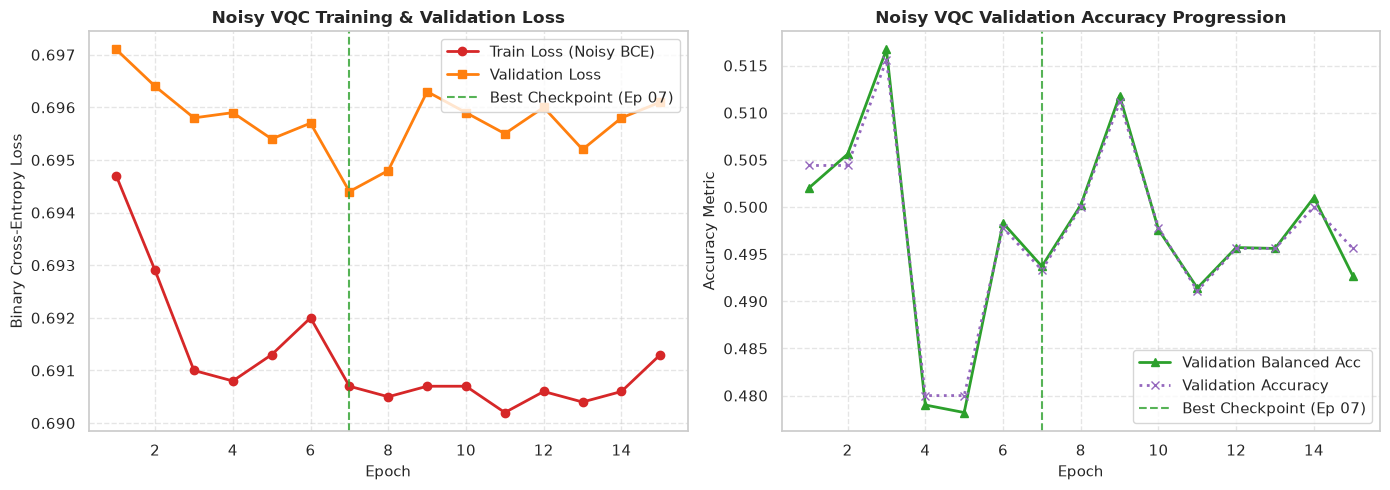

In [5]:
# ==============================================================================
# 4. PLOT NOISY TRAINING & VALIDATION PROGRESSION
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(history_df["Epoch"], history_df["Train Loss"], marker="o", linewidth=2, label="Train Loss (Noisy BCE)", color="#d62728")
axes[0].plot(history_df["Epoch"], history_df["Val Loss"], marker="s", linewidth=2, label="Validation Loss", color="#ff7f0e")
axes[0].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[0].set_title("Noisy VQC Training & Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Balanced Accuracy Curves
axes[1].plot(history_df["Epoch"], history_df["Val Balanced Acc"], marker="^", linewidth=2, label="Validation Balanced Acc", color="#2ca02c")
axes[1].plot(history_df["Epoch"], history_df["Val Accuracy"], marker="x", linewidth=2, linestyle=":", label="Validation Accuracy", color="#9467bd")
axes[1].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[1].set_title("Noisy VQC Validation Accuracy Progression", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy Metric", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_noisy_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 5. Final Out-of-Sample Evaluation on Holdout Test Set

We evaluate the optimal checkpointed Noisy VQC model against the 450 unseen holdout patient samples from `X_test_4.csv`.


 FINAL NOISY TEST SET EVALUATION REPORT (450 SAMPLES)
Accuracy:                 52.67%
Balanced Accuracy:        52.70%
Sensitivity (Recall):     49.34%
Specificity:              56.05%
Precision:                53.33%
F1-Score:                 51.26%
ROC-AUC:                  0.5174
--------------------------------------------------------------------------------
Confusion Matrix: TN=125, FP=98, FN=115, TP=112


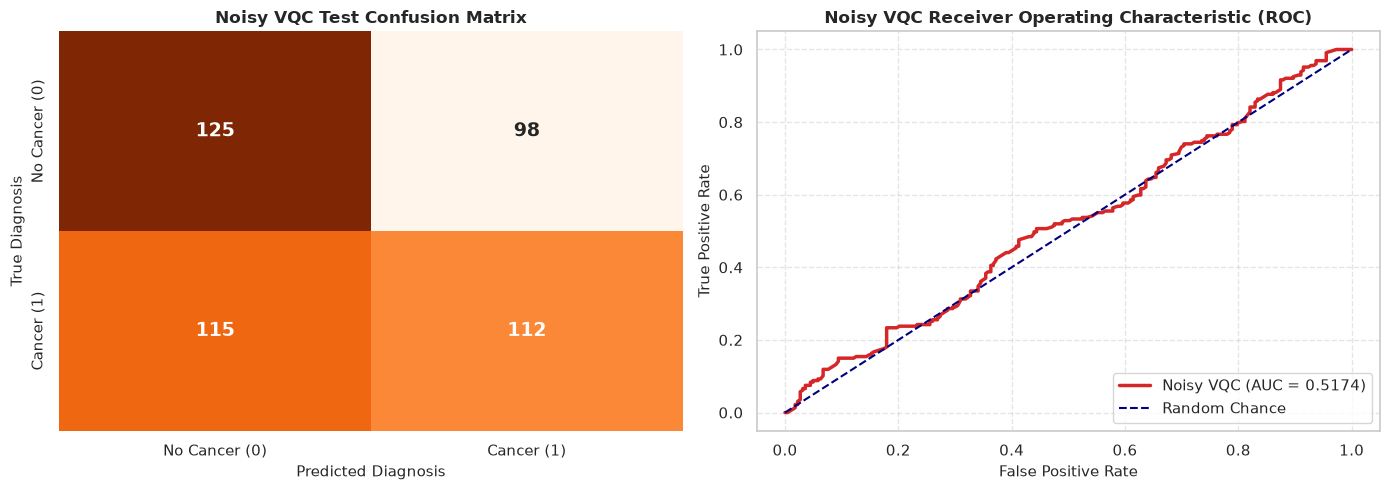

In [6]:
# ==============================================================================
# 5. HOLDOUT TEST SET EVALUATION (NOISY VQC)
# ==============================================================================

X_test_pnp = pnp.array(X_test, requires_grad=False)
test_probs = np.array(forward_probabilities(X_test_pnp, best_weights, best_bias))
test_preds = (test_probs >= 0.5).astype(int)

test_acc = float(accuracy_score(y_test, test_preds))
test_bacc = float(balanced_accuracy_score(y_test, test_preds))
test_sens = float(recall_score(y_test, test_preds, pos_label=1))
test_spec = float(recall_score(y_test, test_preds, pos_label=0))
test_prec = float(precision_score(y_test, test_preds, pos_label=1, zero_division=0))
test_f1 = float(f1_score(y_test, test_preds, pos_label=1, zero_division=0))
test_auc = float(roc_auc_score(y_test, test_probs))
cm = confusion_matrix(y_test, test_preds)

print("================================================================================")
print(" FINAL NOISY TEST SET EVALUATION REPORT (450 SAMPLES)")
print("================================================================================")
print(f"Accuracy:                 {test_acc * 100:.2f}%")
print(f"Balanced Accuracy:        {test_bacc * 100:.2f}%")
print(f"Sensitivity (Recall):     {test_sens * 100:.2f}%")
print(f"Specificity:              {test_spec * 100:.2f}%")
print(f"Precision:                {test_prec * 100:.2f}%")
print(f"F1-Score:                 {test_f1 * 100:.2f}%")
print(f"ROC-AUC:                  {test_auc:.4f}")
print("--------------------------------------------------------------------------------")
print(f"Confusion Matrix: TN={cm[0, 0]}, FP={cm[0, 1]}, FN={cm[1, 0]}, TP={cm[1, 1]}")
print("================================================================================")

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[0],
            xticklabels=["No Cancer (0)", "Cancer (1)"],
            yticklabels=["No Cancer (0)", "Cancer (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Noisy VQC Test Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Diagnosis", fontsize=11)
axes[0].set_ylabel("True Diagnosis", fontsize=11)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color="#d62728", lw=2.5, label=f"Noisy VQC (AUC = {test_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance")
axes[1].set_title("Noisy VQC Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_noisy_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 6. Performance Comparison: Noiseless VQC vs. Noisy VQC

We load the baseline metrics from `Train_models/Hybrid_Quantum_ML/4-feature_Vqc/test_metrics.json` and plot a comparative analysis to assess the impact of NISQ noise channels.


Saved: noisy_test_metrics.json
Saved: vqc_noisy_weights.npy & vqc_noisy_bias.npy
Saved: noisy_training_history.csv


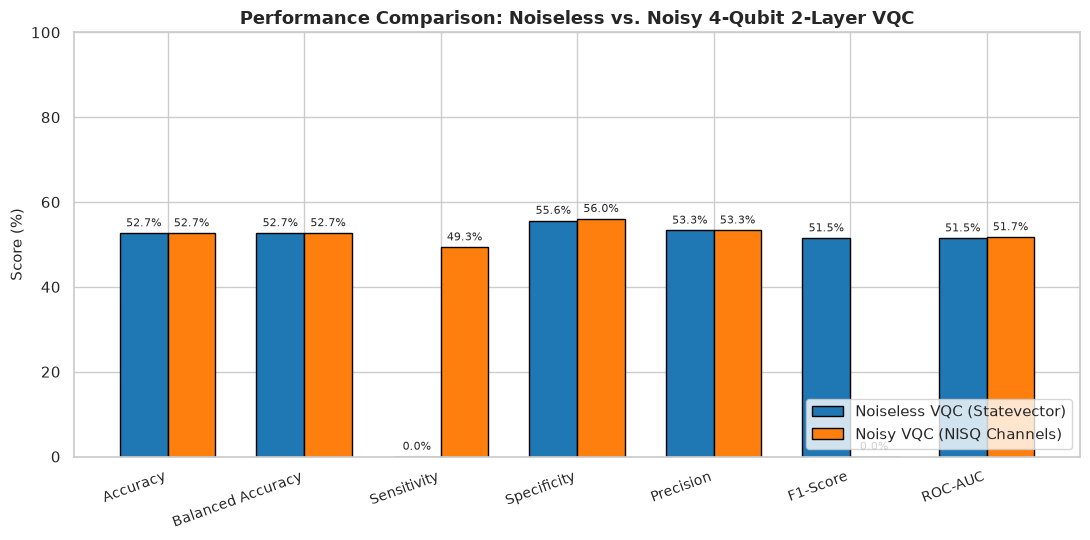

Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/4-Feature_VQC_Noisy/figures/noise_impact_comparison.png

             4-QUBIT NOISY VQC TRAINING & EVALUATION COMPLETE


In [7]:
# ==============================================================================
# 6. NOISE IMPACT COMPARISON & METRICS EXPORT
# ==============================================================================

# Export Noisy Metrics Summary JSON
noisy_test_summary = {
    "model": "4-Qubit Noisy Variational Quantum Classifier (VQC)",
    "framework": f"PennyLane {qml.__version__}",
    "device": "default.mixed (density matrix simulator)",
    "noise_model": {
        "single_qubit_depolarizing": p_gate,
        "two_qubit_depolarizing": p_cnot,
        "measurement_bit_flip": p_meas
    },
    "features": selected_features,
    "metrics": {
        "Accuracy": round(test_acc, 4),
        "Balanced Accuracy": round(test_bacc, 4),
        "Sensitivity": round(test_sens, 4),
        "Specificity": round(test_spec, 4),
        "Precision": round(test_prec, 4),
        "F1-score": round(test_f1, 4),
        "ROC-AUC": round(test_auc, 4)
    },
    "confusion_matrix": {
        "True Negative": int(cm[0, 0]),
        "False Positive": int(cm[0, 1]),
        "False Negative": int(cm[1, 0]),
        "True Positive": int(cm[1, 1])
    }
}

with open(OUTPUT_MODEL_DIR / "noisy_test_metrics.json", "w") as f:
    json.dump(noisy_test_summary, f, indent=4)

print("Saved: noisy_test_metrics.json")
print("Saved: vqc_noisy_weights.npy & vqc_noisy_bias.npy")
print("Saved: noisy_training_history.csv")

# Comparison with Noiseless Baseline
noiseless_metrics_file = NOISELESS_DIR / "test_metrics.json"
if noiseless_metrics_file.exists():
    with open(noiseless_metrics_file, "r") as f:
        noiseless_data = json.load(f)
    nl_metrics = noiseless_data["metrics"]
    
    comp_labels = ["Accuracy", "Balanced Accuracy", "Sensitivity", "Specificity", "Precision", "F1-Score", "ROC-AUC"]
    noiseless_vals = [nl_metrics.get(k, 0.0) for k in comp_labels]
    noisy_vals = [noisy_test_summary["metrics"].get(k, 0.0) for k in comp_labels]
    
    x = np.arange(len(comp_labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(11, 5.5))
    rects1 = ax.bar(x - width/2, [v * 100 if v <= 1.0 else v for v in noiseless_vals], width, label="Noiseless VQC (Statevector)", color="#1f77b4", edgecolor="black")
    rects2 = ax.bar(x + width/2, [v * 100 if v <= 1.0 else v for v in noisy_vals], width, label="Noisy VQC (NISQ Channels)", color="#ff7f0e", edgecolor="black")
    
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_title("Performance Comparison: Noiseless vs. Noisy 4-Qubit 2-Layer VQC", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(comp_labels, rotation=20, ha="right", fontsize=10)
    ax.legend(loc="lower right")
    ax.set_ylim(0, 100)
    
    for rect in rects1:
        h = rect.get_height()
        ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
    for rect in rects2:
        h = rect.get_height()
        ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
        
    plt.tight_layout()
    comp_fig_path = FIGURES_DIR / "noise_impact_comparison.png"
    plt.savefig(comp_fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {comp_fig_path}")

print("\n================================================================================")
print("             4-QUBIT NOISY VQC TRAINING & EVALUATION COMPLETE")
print("================================================================================")
